In [ ]:
!pip install -q gdown

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats
import numpy as np
from scipy.interpolate import interp1d
from scipy.stats import norm

In [ ]:
import random
from scipy import optimize
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Curva de rotación de una Galaxia**

Una buena aproximación al movimiento de las estrellas en las galaxias espirales, es que las estrellas en el disco se mueven siguiendo órbitas circulares. Estas órbitas circulares tienen una velocidad circular que
varía con la distancia al centro $V_c(R)$.
Las observaciones permiten obtener información de la curva de rotación de la galaxia, que corresponde a la medición de la velocidad circular de la galaxia en la forma de pares de datos R (Distancia al centro) y
$V_c(R)$ velocidad circular a ese radio.

Un modelo con el que se puede describir estas observaciones está dado por:

$$
V_{c}(R)=\sqrt{V_{c h}^{2}(R)+V_{c d}^{2}(R)}
$$

$$
V_{c d}^{2}(R)={\frac{G M_{d}R}{[R^{2}+(a+b)^{2}]^{3/2}}}
$$

$$
V_{c h}^{2}(R)=\frac{G M_{h}R}{(R+r_{s})^{2}}
$$

Donde $M_d$, $M_h$ y $r_s$ son parámetros libres del modelo y $a = 7$ y $b = 0.5$. ($M_d$ representa la masa del disco,
$M_h$ la masa del halo y $r_s$ la escala de tamaño del halo de la galaxia)
La tabla de datos anexa tiene la curva de rotación observada para una galaxia espiral real. Los datos son($R_i$, $V_c$,$i$, $σ_i$). La primera columna es $R_i$ en Kpc y la segunda columna es $V_c$,$i$ medida en km/s y la tercera es el error en $V_c$,$i$ también medido en km/s.

## **Unidades canonicas**

Recomiendo que usen un sistema de unidades en el que la constante gravitacional G = 43007.1. En ese
sistema de unidades, se tiene que:
- Unidad de masa = 1010Msun
- Unidad de longitud = 1Kpc
- Unidad de tiempo = 1.1Gyr
- Unidad de velocidad = 1km/s

In [ ]:
G=43007.1
UM=1e10 #Msun
UL=1 #Kpc
UT=1.1 #Gyr
UV=1 #km/s

## **Tabla de datos**

In [ ]:
# Leer el archivo con Pandas
data = pd.read_csv('/content/drive/MyDrive/AstroEstadistica/Rotcurve_con_errores.dat', delimiter='\s+', header=None)  # Ajusta el delimitador si es necesario

# Cambiar el nombre de las columnas
nuevos_nombres = ['Distancia [Kpc]', 'Velocidad [km/s]', 'Error [km/s]']  # Reemplaza con los nombres deseados
data.columns = nuevos_nombres


In [ ]:
# Eliminar la primera fila
data = data.drop(0)


In [ ]:
#data

##**Primer Punto**

Utilice el formalismo Bayesiano para estimar las distribuciones posteriores para Md, Mh y rs. Tenga
en cuenta las siguientes consideraciones:


Del formalismo bayesiano se tiene :
$$P(\vec{\theta}|M)=\frac{P(M|\vec{\theta})P(\vec{\theta})}{P(M)}$$

###**Likelihood**


- Considere que las incertidumbres en las medidas de la velocidad circular de las galaxias se distribuye
gausianamente.


$$P(M|\vec{\theta})=\prod_{i=1}^{n}f(\epsilon _i)$$

$$P(M|\vec{\theta})=\prod_{i=1}^{n}f(\epsilon _i)$$


$$P(M|\vec{\theta})=\prod_{i=1}^{n}\frac{1}{\sqrt{2\pi \sigma^{2}}}e^{\frac{-\epsilon _i^{2}}{2\sigma^{2}}}$$

Usemos:

$$\epsilon _i=V_{c,i}-V_{c}(R)$$

$$\boxed{\epsilon _i=V_{c,i}-\sqrt{V_{c h}^{2}(R)+V_{c d}^{2}(R)}}$$

### **Priors**


Los prios al ser un estado de información previa se evalua según lo que se haya estudiado de mi problema en cuestión. Siempre hay una forma de cuantificar o modelar mi prior, de este modo, tomemos como prior nulo o no informativo el hecho de que mis parametros siguen una distribución uniforme, donde a su vez estan restringidos por hyperparams.

In [ ]:
#Datos como arreglos
err=np.array(data.iloc[:, 2]) #COLUMNAS
V_ci=np.array(data.iloc[:, 1])
R_i=np.array(data.iloc[:, 0])

In [ ]:
#Longitud de mis arregos
NDATA=len(R_i)
NDATA

32

$$
V_{c}(R)=\sqrt{V_{c h}^{2}(R)+V_{c d}^{2}(R)}
$$

$$
V_{c d}^{2}(R)={\frac{G M_{d}R}{[R^{2}+(a+b)^{2}]^{3/2}}}
$$

$$
V_{c h}^{2}(R)=\frac{G M_{h}R}{(R+r_{s})^{2}}
$$

Haciendo un analisis sobre las incertidumbres se puede observar que se puede aproximar los valores de errores a un valor promedio.

### **Primera visualización de los datos**

In [ ]:

a = 7
b = 0.5
def f_model(R,Md,Mh,rs):
  Vch2 = G*Mh*R/(R+rs)**2
  Vcd2 = G*Md*R/((R**2+(7+0.5)**2)**(3/2))
  Vc = np.sqrt(Vch2 + Vcd2)
  return Vc

In [ ]:
mdata = np.empty(len(R_i))
for i in range(NDATA):
        mdata[i] = f_model(R_i[i],Md=6,Mh=30,rs=15)

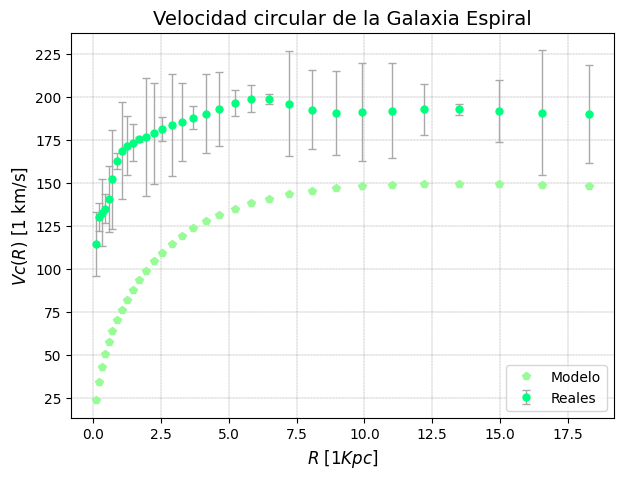

In [ ]:
plt.figure(figsize=(7,5))
plt.errorbar(R_i, V_ci,yerr=mdata,lw=0,elinewidth=1,color='springgreen',ecolor='darkgrey', fmt='o',capsize=3,markersize=5,label = 'Reales')
plt.plot(R_i,mdata, "p", color = 'palegreen',label = 'Modelo')
#plt.plot(R_i, V_ci, "o", color = '#27AE60', label = 'Reales')
plt.title("Velocidad circular de la Galaxia Espiral",fontsize=14)
plt.xlabel("$R$ [$1 Kpc$]",fontsize=12)
plt.ylabel("$Vc(R)$ [1 km/s]",fontsize=12)

plt.grid(color='#414446', linestyle='--', linewidth=0.2)
plt.legend()
plt.show()

AL observar esto puedo decir que la eleccion de los parametros es crucial para ajustar mi evidencia a el modolo, nnuestro primer paso sera utilizar un ajuste o curvfit para obtener una primera aproximacion de mis mejores parametros, para finalmente usar formalismo bayesiano y tener mis parametros mas acertados.

In [ ]:
def kerneli(R, Vc, sigma, Md, Mh, rs):
    mi = f_model(R, Md, Mh, rs)
    fac = np.abs(Vc - mi) * np.abs(Vc - mi)
    if ((Vc > mi - sigma) and (Vc < mi + sigma)):
        window = np.exp(-0.5 * fac / (sigma ** 2))
    else:
        window = 0.0

    return window



In [ ]:
def likelihood(Ri, V, sigma, md,mh,rs):
    like = 1.0
    for i in range(len(R_i)):
        value = 1/sigma[i] * np.exp(-((V[i]-f_model(Ri[i],md,mh,rs))**2)/(2*sigma[i]**2))
        if value > 0:
          like = like*value

    return like

####**Optimización**

In [ ]:
vGuess = [0.3,10,8]
vTrial, aCova = optimize.curve_fit(f_model, R_i, V_ci, vGuess)
e1, e2, e3 = vTrial
e1,e2,e3

(-137.9046184642964, 34.83810933010086, 4.945256957711905)

In [ ]:
Md, Mh, rs = e1,e2,e3

In [ ]:
likelihood_vector = np.empty(len(R_i))
for i in range(len(R_i)):
        likelihood_vector[i] = kerneli(R_i[i], V_ci[i], err[i], Md, Mh, rs)

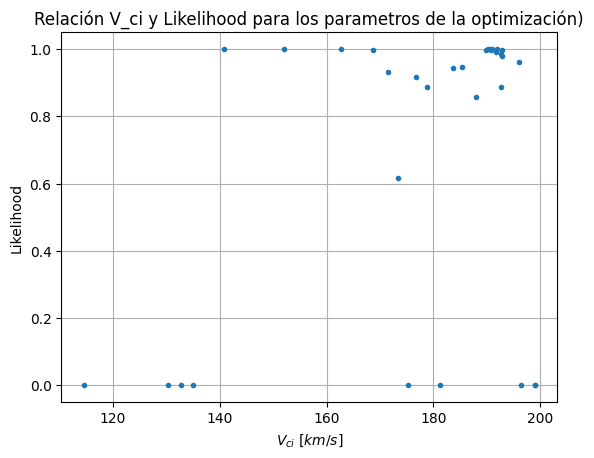

In [ ]:
plt.plot(V_ci, likelihood_vector, ".")
plt.xlabel(r"$V_{ci}$ $[km/s]$")
plt.ylabel("Likelihood")
plt.title("Relación V_ci y Likelihood para los parametros de la optimización)")
plt.grid(True)  # Agrega la grilla al gráfico
plt.show()

In [ ]:
Md_mina = 1e9/UM
Md_maxa = 1e11/UM
Mh_mina = 1e10/UM
Mh_maxa = 1e12/UM
rs_mina = 1
rs_maxa = 50
Mh_mina,Mh_maxa


(1.0, 100.0)

In [ ]:
Md_SAMPLES = 50
Mh_SAMPLES = 50
rs_SAMPLES = 50


dMd = (Md_maxa-Md_mina)/(1.0*Md_SAMPLES)
dMh = (Mh_maxa-Mh_mina)/(1.0*Mh_SAMPLES)
drs = (rs_maxa-Mh_mina)/(1.0*Mh_SAMPLES)

Md = Md_mina
Mdvector    = np.empty(Md_SAMPLES*Mh_SAMPLES*rs_SAMPLES)
Mhvector    = np.empty(Md_SAMPLES*Mh_SAMPLES*rs_SAMPLES)
rsvector    = np.empty(Md_SAMPLES*Mh_SAMPLES*rs_SAMPLES)


likevector = np.empty(Md_SAMPLES*Md_SAMPLES*rs_SAMPLES)
count = 0
for k in range(Md_SAMPLES):
    Mh = Mh_mina
    for l in range(Md_SAMPLES):
      rs = rs_mina
      for m in range(Md_SAMPLES):
        Mdvector[count] = Md
        Mhvector[count] = Mh
        rsvector[count] = rs
        value = likelihood(R_i, V_ci, err, Md, Mh, rs)
        likevector[count] = value
        rs = rs+drs
        count = count+1
      Mh = Mh+dMh
    Md = Md+dMd



- Muestre gráficamente como es la distribución de probabilidad posterior P(Md), P(Mh) y P(rs).


- Entregue una estimaci ́on para el valor de cada uno de los par ́ametros del modelo (Md, Mh y rs) y
entregue barras de error. Explique como hizo su estimaciones y justif ́ıquelas.

In [ ]:
print("MAP=%.8e Md_MAP=%.8f Mh_MAP=%.8f rs_MAP=%.8f" %(likevector.max(), Mdvector[likevector.argmax()], Mhvector[likevector.argmax()],rsvector[likevector.argmax()]))

MAP=6.78539332e+53 Md_MAP=0.10000000 Mh_MAP=18.82000000 rs_MAP=4.92000000


In [ ]:
MAP_Md,MAP_Mh,MAP_rs= Mdvector[likevector.argmax()], Mhvector[likevector.argmax()],rsvector[likevector.argmax()]
MAP_Md,MAP_Mh,MAP_rs

(0.6940000000000001, 18.82, 4.92)

In [ ]:
mdata2 = np.empty(len(R_i))
for i in range(NDATA):
        mdata2[i] = f_model(R_i[i],MAP_Md,MAP_Mh,MAP_rs)

In [ ]:
mdataf = np.empty(len(R_i))
for i in range(len(R_i)):
        mdataf[i] = err[i]

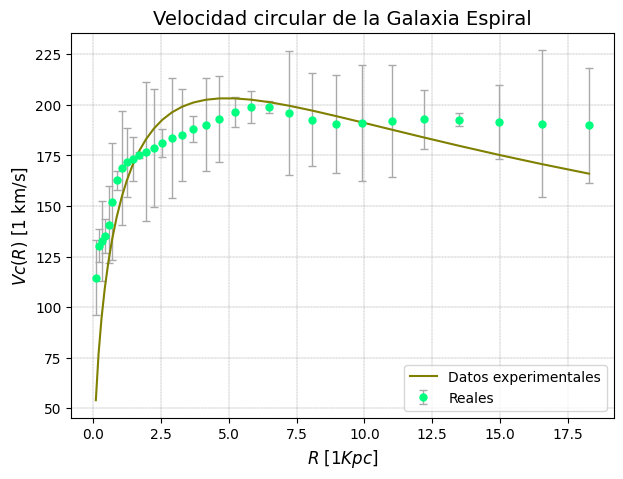

In [ ]:
plt.figure(figsize=(7,5))
plt.errorbar(R_i, V_ci,yerr=mdataf,lw=0,elinewidth=1,color='springgreen',ecolor='darkgrey', fmt='o',capsize=3,markersize=5,label = 'Reales')
plt.plot(R_i,f_model(R_i,MAP_Md,MAP_Mh,MAP_rs),color='olive',label = 'Datos experimentales')
#plt.plot(R_i, V_ci, "o", color = '#27AE60', label = 'Reales')
plt.title("Velocidad circular de la Galaxia Espiral",fontsize=14)
plt.xlabel("$R$ [$1 Kpc$]",fontsize=12)
plt.ylabel("$Vc(R)$ [1 km/s]",fontsize=12)

plt.grid(color='#414446', linestyle='--', linewidth=0.2)
plt.legend()
plt.show()